Import Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

Load CSV files

In [13]:
tahoe_df = pd.read_csv("log_tahoe.csv")
reno_df = pd.read_csv("log_reno.csv")

tahoe_df.head(), reno_df.head()

(   Round  cwnd  ssthresh   mode
 0      1     1         8  TAHOE
 1      2     2         8  TAHOE
 2      3     4         8  TAHOE
 3      4     8         8  TAHOE
 4      5     1         4  TAHOE,
    Round  cwnd  ssthresh  mode
 0      1     1         8  RENO
 1      2     2         8  RENO
 2      3     4         8  RENO
 3      4     8         8  RENO
 4      5     4         4  RENO)

Plot congestion window (cwnd) and threshold (ssthresh)

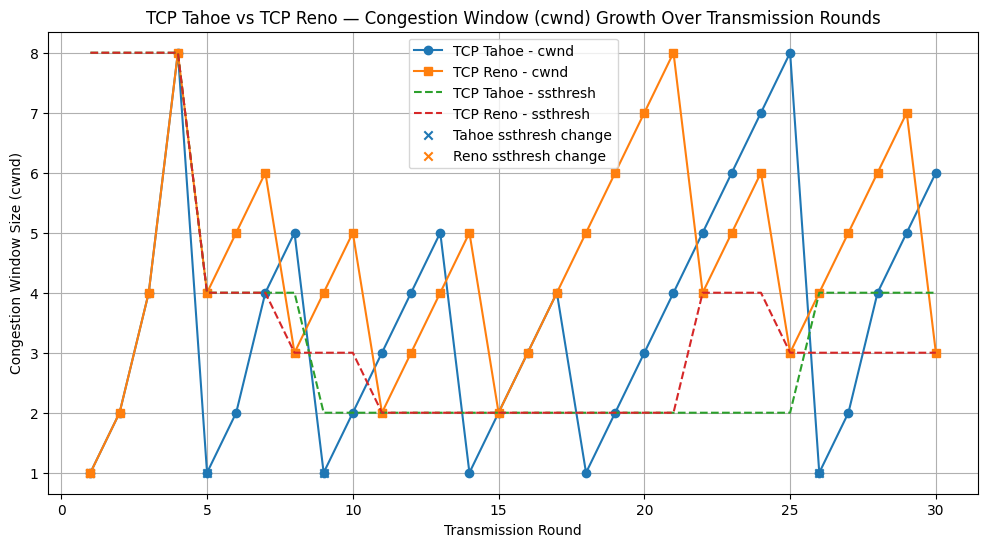

In [14]:
plt.figure(figsize=(12, 6))

# Plot cwnd growth
plt.plot(tahoe_df["Round"], tahoe_df["cwnd"], marker='o', label="TCP Tahoe - cwnd")
plt.plot(reno_df["Round"], reno_df["cwnd"], marker='s', label="TCP Reno - cwnd")

# Plot ssthresh
plt.plot(tahoe_df["Round"], tahoe_df["ssthresh"], linestyle='--', label="TCP Tahoe - ssthresh")
plt.plot(reno_df["Round"], reno_df["ssthresh"], linestyle='--', label="TCP Reno - ssthresh")

# Highlight ssthresh change points
tahoe_ssthresh_changes = tahoe_df[tahoe_df["ssthresh"].diff() != 0]
reno_ssthresh_changes = reno_df[reno_df["ssthresh"].diff() != 0]

plt.scatter(tahoe_ssthresh_changes["Round"], tahoe_ssthresh_changes["cwnd"], marker='x', label="Tahoe ssthresh change")
plt.scatter(reno_ssthresh_changes["Round"], reno_ssthresh_changes["cwnd"], marker='x', label="Reno ssthresh change")

plt.title("TCP Tahoe vs TCP Reno — Congestion Window (cwnd) Growth Over Transmission Rounds")
plt.xlabel("Transmission Round")
plt.ylabel("Congestion Window Size (cwnd)")
plt.grid(True)
plt.legend()
plt.show()


Save the plot

In [15]:
plt.savefig("tcp_tahoe_vs_reno_graph.png")

<Figure size 640x480 with 0 Axes>